In [20]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# 讀取 JSON 檔案
with open('benchmark_results_20260124.json', 'r') as f:
    data = json.load(f)

# 轉換成 DataFrame
df = pd.DataFrame(data)

# 定義區分度高的樣式（顏色 + 標記 + 線型）
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
linestyles = ['-', '--', '-.', ':', '-', '--']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']



In [21]:
print(f"data length: {len(df)}")
print(f"df head(5)")
print(df.head(5))


data length: 264
df head(5)
   num_tx  num_rx  depth  num_samples  avg_path_time  std_path_time  \
0       1       1      3           10       0.030893       0.014191   
1       1       1      4           10       0.027875       0.012279   
2       1       1      5           10       0.028077       0.011880   
3       1       1      6           10       0.028676       0.011004   
4       1       1      7           10       0.027979       0.011208   

   avg_render_time  std_render_time  \
0                0                0   
1                0                0   
2                0                0   
3                0                0   
4                0                0   

                                      all_path_times all_render_times  
0  [0.07257533073425293, 0.0284576416015625, 0.03...               []  
1  [0.06355047225952148, 0.026536226272583008, 0....               []  
2  [0.06316208839416504, 0.021977663040161133, 0....               []  
3  [0.0602927207946777

In [41]:
TITLE_SIZE = 16      # 標題字體大小
LABEL_SIZE = 14      # xy軸標籤字體大小
TICK_SIZE = 12       # xy軸刻度字體大小
LEGEND_SIZE = 11     # 圖例字體大小



# # 使用變數設定字體大小
# ax.set_xlabel('Number of RX', fontsize=LABEL_SIZE, fontweight='bold')
# ax.set_ylabel('Average Path Time (s)', fontsize=LABEL_SIZE, fontweight='bold')
# ax.set_title(f'Path Time vs RX (Depth={depth_fixed})', fontsize=TITLE_SIZE, fontweight='bold')

# # 設定刻度字體大小
# ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE)

# # 設定圖例字體大小
# ax.legend(fontsize=LEGEND_SIZE, frameon=True, shadow=True)


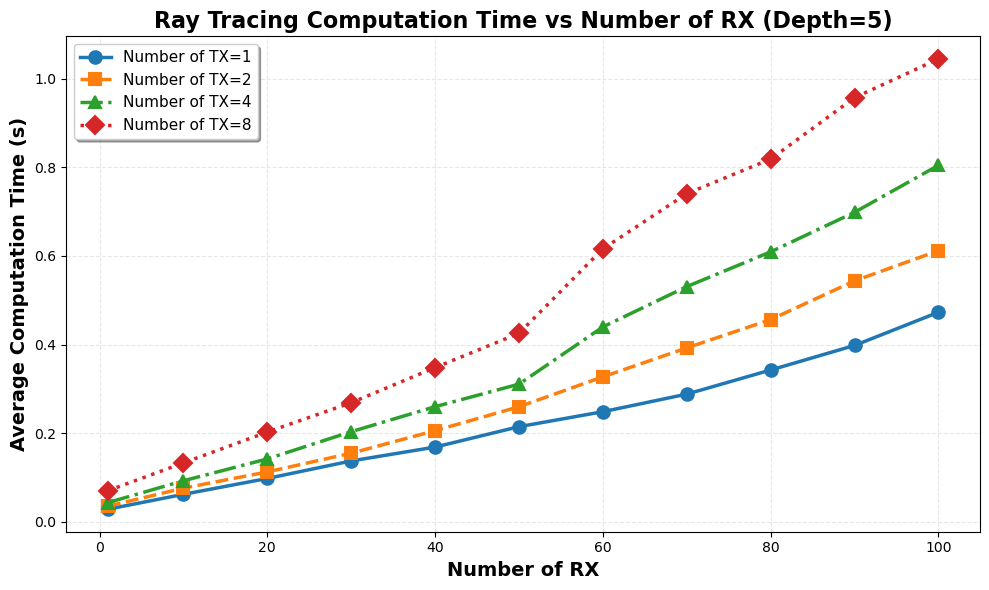

In [51]:
# ==================== 圖1 ====================
# 固定 depth=5, x軸是 num_rx, 不同 num_tx 的線
fig, ax = plt.subplots(figsize=(10, 6))
depth_fixed = 5
subset = df[df['depth'] == depth_fixed]

tx_values = sorted(subset['num_tx'].unique())
for idx, num_tx in enumerate(tx_values):
    data_tx = subset[subset['num_tx'] == num_tx].sort_values('num_rx')
    ax.plot(data_tx['num_rx'], data_tx['avg_path_time'], 
            marker=markers[idx], linestyle=linestyles[idx],
            color=colors[idx], linewidth=2.5, markersize=9, 
            markeredgewidth=1.5, markeredgecolor=colors[idx],
            label=f'Number of TX={num_tx}')
    
ax.set_xlabel('Number of RX', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Average Computation Time (s)', fontsize=LABEL_SIZE, fontweight='bold')

ax.set_title(f'Ray Tracing Computation Time vs Number of RX (Depth={depth_fixed})', fontsize=TITLE_SIZE, fontweight='bold')
ax.legend(fontsize=LEGEND_SIZE, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('rt_time_vs_num_rx.png', dpi=300, bbox_inches='tight')
# plt.savefig('fig1_rx_scaling.pdf', bbox_inches='tight')
plt.show()

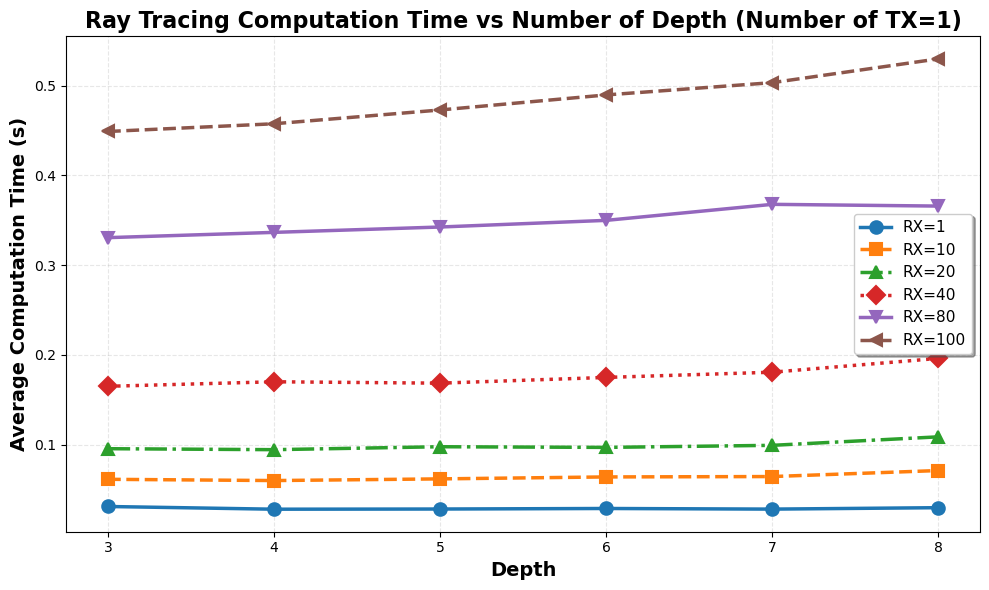

In [52]:
# ==================== 圖2 ====================
# 固定 num_tx=1, x軸是 depth, 選擇代表性 num_rx
fig, ax = plt.subplots(figsize=(10, 6))
tx_fixed = 1
subset = df[df['num_tx'] == tx_fixed]
selected_rx = [1, 10, 20, 40, 80, 100]

for idx, num_rx in enumerate(selected_rx):
    data_rx = subset[subset['num_rx'] == num_rx].sort_values('depth')
    if len(data_rx) > 0:
        ax.plot(data_rx['depth'], data_rx['avg_path_time'], 
                marker=markers[idx], linestyle=linestyles[idx],
                color=colors[idx], linewidth=2.5, markersize=9,
                markeredgewidth=1.5, markeredgecolor=colors[idx],
                label=f'RX={num_rx}')

ax.set_xlabel('Depth', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Average Computation Time (s)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title(f'Ray Tracing Computation Time vs Number of Depth (Number of TX={tx_fixed})', fontsize=TITLE_SIZE, fontweight='bold')
ax.legend(fontsize=LEGEND_SIZE, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('rt_time_vs_num_depth.png', dpi=300, bbox_inches='tight')
# plt.savefig('fig2_depth_effect.pdf', bbox_inches='tight')
plt.show()

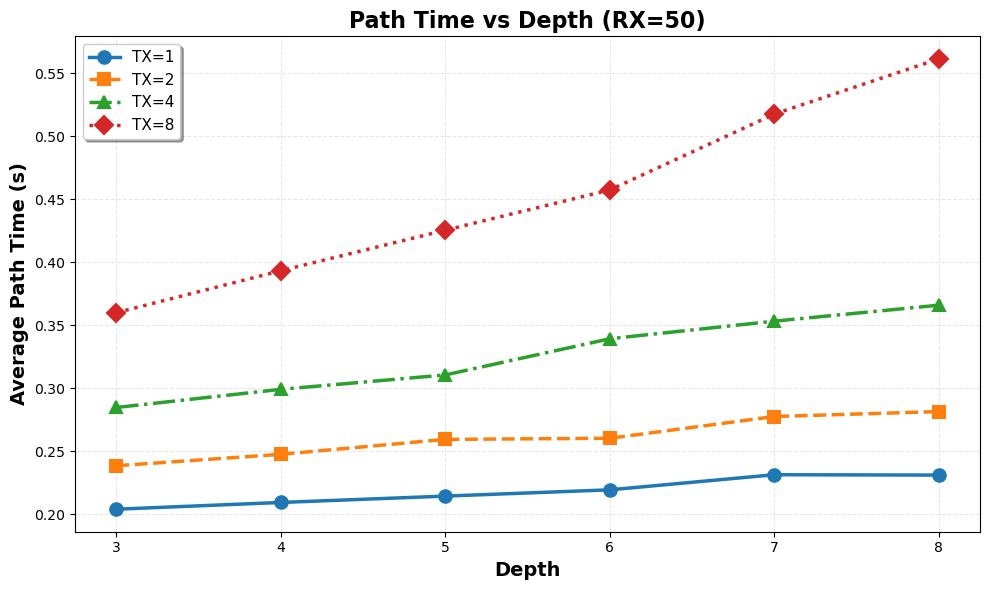

In [45]:
# ==================== 圖3 ====================
# 固定 num_rx=50, x軸是 depth, 不同 num_tx 的線
fig, ax = plt.subplots(figsize=(10, 6))
rx_fixed = 50
subset = df[df['num_rx'] == rx_fixed]

tx_values = sorted(subset['num_tx'].unique())
for idx, num_tx in enumerate(tx_values):
    data_tx = subset[subset['num_tx'] == num_tx].sort_values('depth')
    ax.plot(data_tx['depth'], data_tx['avg_path_time'], 
            marker=markers[idx], linestyle=linestyles[idx],
            color=colors[idx], linewidth=2.5, markersize=9,
            markeredgewidth=1.5, markeredgecolor=colors[idx],
            label=f'TX={num_tx}')

ax.set_xlabel('Depth', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_ylabel('Average Path Time (s)', fontsize=LABEL_SIZE, fontweight='bold')
ax.set_title(f'Path Time vs Depth (RX={rx_fixed})', fontsize=TITLE_SIZE, fontweight='bold')
ax.legend(fontsize=LEGEND_SIZE, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
# plt.savefig('fig3_tx_depth_interaction.png', dpi=300, bbox_inches='tight')
# plt.savefig('fig3_tx_depth_interaction.pdf', bbox_inches='tight')
plt.show()

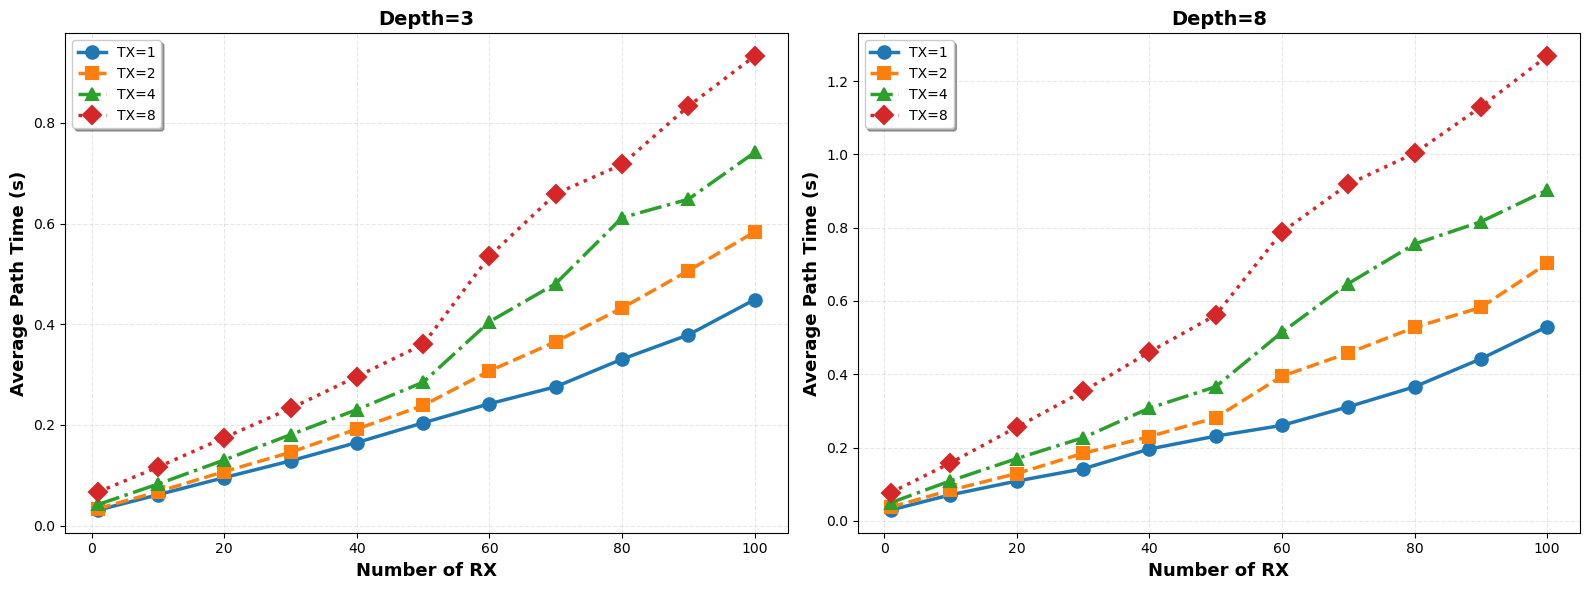

In [47]:
# ==================== 替代圖3-A（兩個subplot）====================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, depth_val in enumerate([3, 8]):
    ax = axes[ax_idx]
    subset = df[df['depth'] == depth_val]
    
    tx_values = sorted(subset['num_tx'].unique())
    for idx, num_tx in enumerate(tx_values):
        data_tx = subset[subset['num_tx'] == num_tx].sort_values('num_rx')
        ax.plot(data_tx['num_rx'], data_tx['avg_path_time'], 
                marker=markers[idx], linestyle=linestyles[idx],
                color=colors[idx], linewidth=2.5, markersize=9,
                markeredgewidth=1.5, markeredgecolor=colors[idx],
                label=f'TX={num_tx}')
    
    ax.set_xlabel('Number of RX', fontsize=13, fontweight='bold')
    ax.set_ylabel('Average Path Time (s)', fontsize=13, fontweight='bold')
    ax.set_title(f'Depth={depth_val}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
# plt.savefig('fig3_alt_depth_comparison.png', dpi=300, bbox_inches='tight')
# plt.savefig('fig3_alt_depth_comparison.pdf', bbox_inches='tight')
plt.show()

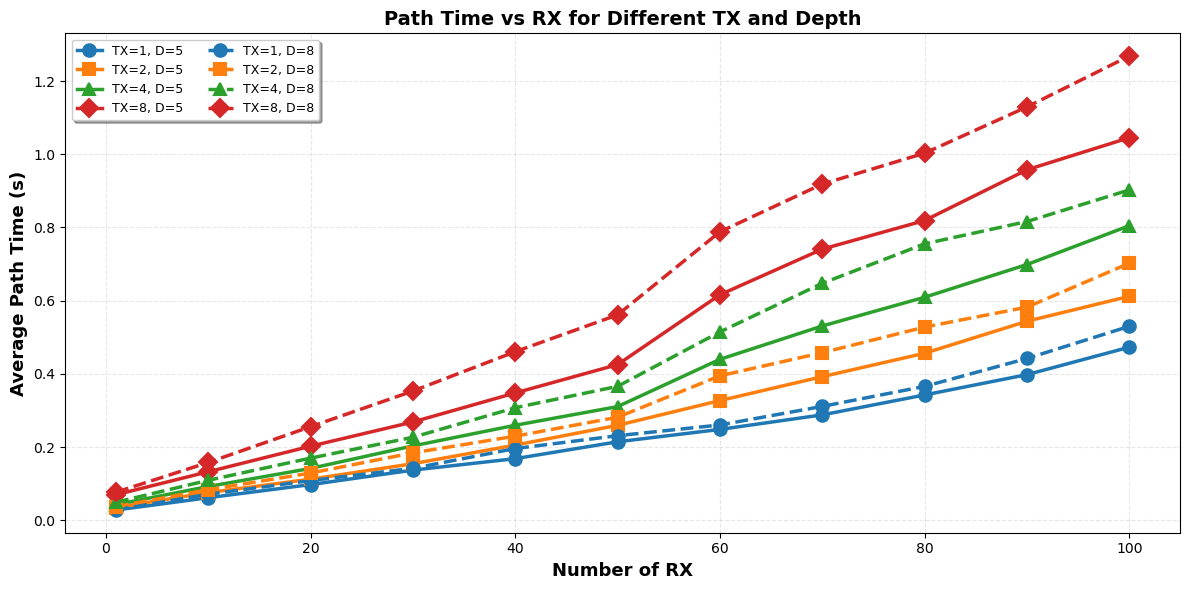

In [26]:
# ==================== 替代圖3-B（單圖雙深度）====================
fig, ax = plt.subplots(figsize=(12, 6))

depth_vals = [5, 8]
tx_values = sorted(df['num_tx'].unique())

style_idx = 0
for d_idx, depth_val in enumerate(depth_vals):
    subset = df[df['depth'] == depth_val]
    for t_idx, num_tx in enumerate(tx_values):
        data_tx = subset[subset['num_tx'] == num_tx].sort_values('num_rx')
        if len(data_tx) > 0:
            # depth=5 用實線，depth=8 用虛線
            ls = '-' if d_idx == 0 else '--'
            ax.plot(data_tx['num_rx'], data_tx['avg_path_time'], 
                    marker=markers[t_idx], linestyle=ls,
                    color=colors[t_idx], linewidth=2.5, markersize=9,
                    markeredgewidth=1.5, markeredgecolor=colors[t_idx],
                    label=f'TX={num_tx}, D={depth_val}')

ax.set_xlabel('Number of RX', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Path Time (s)', fontsize=13, fontweight='bold')
ax.set_title('Path Time vs RX for Different TX and Depth', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, ncol=2, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
# plt.savefig('fig3_alt_combined.png', dpi=300, bbox_inches='tight')
# plt.savefig('fig3_alt_combined.pdf', bbox_inches='tight')
plt.show()